C:\Users\Rdvel\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(


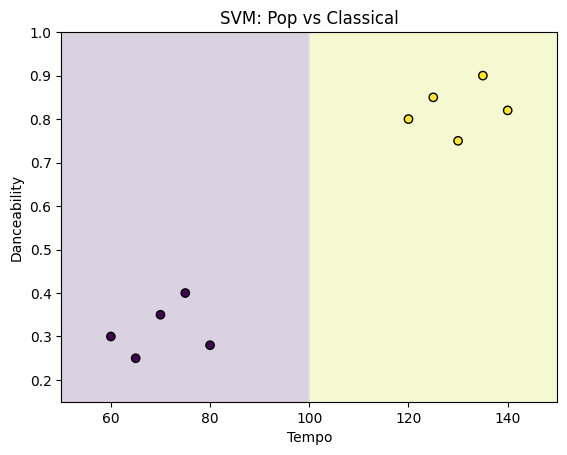

In [1]:
'''Create a simple SVM classifier using scikit-learn to separate two classes of music genres (e.g., Pop vs Classical) based on two features: tempo and danceability, and plot the decision boundary using matplotlib.'''

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.svm import SVC

# Create sample music dataset
data = {
    "tempo": [
        120, 125, 130, 135, 140,       # Pop
        60, 65, 70, 75, 80             # Classical
    ],

    "danceability": [
        0.80, 0.85, 0.75, 0.90, 0.82, # Pop
        0.30, 0.25, 0.35, 0.40, 0.28  # Classical
    ],

    "genre": [
        "Pop", "Pop", "Pop", "Pop", "Pop",
        "Classical", "Classical", "Classical",
        "Classical", "Classical"
    ]
}

df = pd.DataFrame(data)

# Features
X = df[["tempo", "danceability"]]

# Target
y = df["genre"]

# Convert labels to numbers
y = y.map({
    "Classical": 0,
    "Pop": 1
})

# Create SVM classifier
model = SVC(kernel="linear")

# Train the model
model.fit(X, y)

# -----------------------------
# Create decision boundary
# -----------------------------

# Get feature ranges
tempo_min = X["tempo"].min() - 10
tempo_max = X["tempo"].max() + 10

dance_min = X["danceability"].min() - 0.1
dance_max = X["danceability"].max() + 0.1

# Create grid
xx, yy = np.meshgrid(
    np.linspace(tempo_min, tempo_max, 200),
    np.linspace(dance_min, dance_max, 200)
)

# Predict every point in the grid
Z = model.predict(
    np.c_[xx.ravel(), yy.ravel()]
)

Z = Z.reshape(xx.shape)

# Plot decision regions
plt.contourf(xx, yy, Z, alpha=0.2)

# Plot actual data points
plt.scatter(
    X["tempo"],
    X["danceability"],
    c=y,
    edgecolors="black"
)

# Labels
plt.xlabel("Tempo")
plt.ylabel("Danceability")
plt.title("SVM: Pop vs Classical")

plt.show()

In [2]:
'''Given a dataset of Flipkart product reviews labeled as positive or negative, use an SVM with a linear kernel to classify the reviews and print the accuracy score.'''

import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

# Sample Flipkart reviews
data = {
    "review": [
        "Excellent product and very good quality",
        "Amazing product I really liked it",
        "Very useful and worth the money",
        "Good quality and fast delivery",
        "I am very happy with this product",
        "Product is excellent and works perfectly",
        "Very poor quality",
        "Worst product I have ever bought",
        "Not worth the money",
        "Bad quality and disappointing",
        "Product stopped working",
        "Very unhappy with this purchase",
        "Good product and amazing quality",
        "I love this product",
        "Terrible product and poor quality",
        "Waste of money",
        "Excellent value for money",
        "The product is very good",
        "Completely disappointed",
        "I would not recommend this product"
    ],

    "sentiment": [
        "positive", "positive", "positive", "positive", "positive",
        "positive", "negative", "negative", "negative", "negative",
        "negative", "negative", "positive", "positive", "negative",
        "negative", "positive", "positive", "negative", "negative"
    ]
}

df = pd.DataFrame(data)

# Reviews
X = df["review"]

# Labels
y = df["sentiment"]

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Convert text into numerical TF-IDF features
vectorizer = TfidfVectorizer()

X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

# Create SVM with linear kernel
model = SVC(kernel="linear")

# Train
model.fit(X_train_tfidf, y_train)

# Predict
y_pred = model.predict(X_test_tfidf)

# Accuracy
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.5


In [3]:
'''
Train two SVM classifiers on an IPL player performance dataset: one with a polynomial kernel and one with an RBF kernel. Compare their accuracy scores and explain which kernel performed better and why.<br><br><em><strong>Hint:</strong> Use scikit-learn's SVC class and the 'kernel' parameter.</em>'''

import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

# --------------------------------
# Create IPL player dataset
# --------------------------------

data = {
    "runs": [
        450, 520, 300, 150, 600,
        250, 700, 180, 550, 220,
        480, 650, 200, 580, 320,
        720, 170, 490, 270, 610
    ],

    "strike_rate": [
        145, 150, 125, 105, 155,
        115, 160, 110, 148, 120,
        142, 158, 108, 152, 128,
        165, 102, 140, 118, 156
    ],

    "average": [
        42, 45, 30, 18, 48,
        25, 52, 20, 44, 27,
        40, 50, 22, 46, 32,
        55, 19, 41, 26, 49
    ],

    "high_performer": [
        1, 1, 0, 0, 1,
        0, 1, 0, 1, 0,
        1, 1, 0, 1, 0,
        1, 0, 1, 0, 1
    ]
}

df = pd.DataFrame(data)

print(df.head())

# --------------------------------
# Features and target
# --------------------------------

X = df[["runs", "strike_rate", "average"]]
y = df["high_performer"]

# --------------------------------
# Train-test split
# --------------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# --------------------------------
# Feature scaling
# --------------------------------

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# --------------------------------
# Polynomial SVM
# --------------------------------

poly_model = SVC(kernel="poly")

poly_model.fit(X_train, y_train)

poly_pred = poly_model.predict(X_test)

poly_accuracy = accuracy_score(y_test, poly_pred)


# --------------------------------
# RBF SVM
# --------------------------------

rbf_model = SVC(kernel="rbf")

rbf_model.fit(X_train, y_train)

rbf_pred = rbf_model.predict(X_test)

rbf_accuracy = accuracy_score(y_test, rbf_pred)


# --------------------------------
# Compare
# --------------------------------

print("\nPolynomial Kernel Accuracy:", poly_accuracy)
print("RBF Kernel Accuracy:", rbf_accuracy)

if poly_accuracy > rbf_accuracy:
    print("\nPolynomial kernel performed better.")
elif rbf_accuracy > poly_accuracy:
    print("\nRBF kernel performed better.")
else:
    print("\nBoth kernels performed equally.")

   runs  strike_rate  average  high_performer
0   450          145       42               1
1   520          150       45               1
2   300          125       30               0
3   150          105       18               0
4   600          155       48               1

Polynomial Kernel Accuracy: 0.75
RBF Kernel Accuracy: 1.0

RBF kernel performed better.


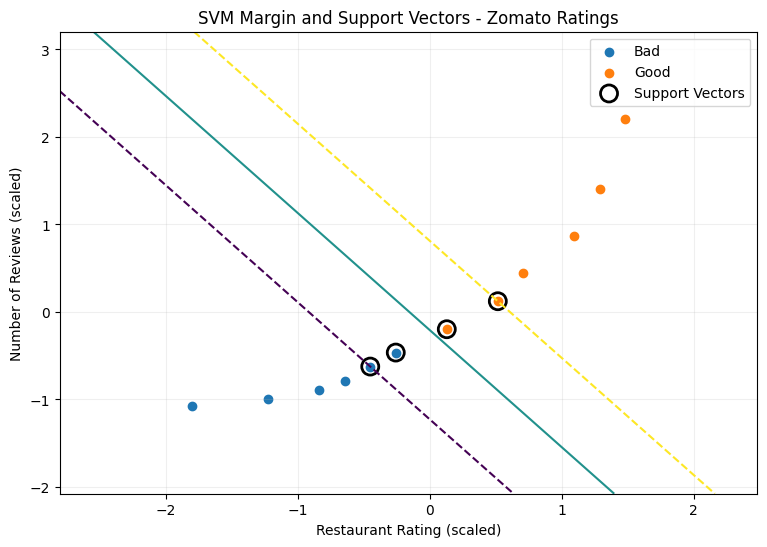

Number of support vectors: 4


In [4]:
'''Use ChatGPT or Copilot to help you write code that visualizes the margin and support vectors for an SVM trained on a two-class Zomato restaurant rating dataset (e.g., 'Good' vs 'Bad' ratings). Paste your code and a screenshot of the plot.'''
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler

# Small Zomato-style dataset
df = pd.DataFrame({
    "restaurant_rating": [2.5, 2.8, 3.0, 3.1, 3.2, 3.3,
                          3.5, 3.7, 3.8, 4.0, 4.1, 4.2],

    "no_of_reviews": [35, 50, 70, 90, 120, 150,
                      200, 260, 320, 400, 500, 650]
})

# Good = rating >= 3.5
# Bad = rating < 3.5
df["label"] = np.where(df["restaurant_rating"] >= 3.5, 1, 0)

# Features and target
X = df[["restaurant_rating", "no_of_reviews"]]
y = df["label"]

# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Create linear SVM
model = SVC(kernel="linear", C=1)

# Train
model.fit(X_scaled, y)

# Create grid
x_min, x_max = X_scaled[:, 0].min() - 1, X_scaled[:, 0].max() + 1
y_min, y_max = X_scaled[:, 1].min() - 1, X_scaled[:, 1].max() + 1

xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 300),
    np.linspace(y_min, y_max, 300)
)

# Decision function
grid = np.c_[xx.ravel(), yy.ravel()]
decision = model.decision_function(grid).reshape(xx.shape)

# Plot decision boundary and margins
plt.figure(figsize=(9, 6))

plt.contour(
    xx, yy, decision,
    levels=[-1, 0, 1],
    linestyles=["--", "-", "--"]
)

# Plot Bad restaurants
plt.scatter(
    X_scaled[y == 0, 0],
    X_scaled[y == 0, 1],
    label="Bad"
)

# Plot Good restaurants
plt.scatter(
    X_scaled[y == 1, 0],
    X_scaled[y == 1, 1],
    label="Good"
)

# Highlight support vectors
plt.scatter(
    model.support_vectors_[:, 0],
    model.support_vectors_[:, 1],
    s=150,
    facecolors="none",
    edgecolors="black",
    linewidths=2,
    label="Support Vectors"
)

plt.xlabel("Restaurant Rating (scaled)")
plt.ylabel("Number of Reviews (scaled)")
plt.title("SVM Margin and Support Vectors - Zomato Ratings")
plt.legend()
plt.grid(alpha=0.2)
plt.show()

print("Number of support vectors:", len(model.support_vectors_))